In [194]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from utils.helpers import encode_data, f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2, l1, l1_l2

pd.set_option('display.max_columns', None)

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# df = encode_data(df)

features = df.drop(columns=["customerID", "Churn"])
target = df["Churn"]    

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.0,0.504756,0.500013,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
Partner,7043.0,0.483033,0.499748,0.00,0.00,0.00,1.00,1.00
Dependents,7043.0,0.299588,0.458110,0.00,0.00,0.00,1.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.0,0.903166,0.295752,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.0,0.615505,0.656039,0.00,0.00,1.00,1.00,2.00
OnlineSecurity,7043.0,0.720006,0.796885,0.00,0.00,1.00,1.00,2.00
OnlineBackup,7043.0,0.778220,0.778472,0.00,0.00,1.00,1.00,2.00
DeviceProtection,7043.0,0.777226,0.778826,0.00,0.00,1.00,1.00,2.00


In [77]:
df.Contract.unique()

array([0, 1, 2])

Tenure, MonthlyCharges, and TotalCharges have a big peak2peak. need feat scaling. 

In [52]:
scaler = StandardScaler()
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

features_scaled = features.copy()
features_scaled[cols] = scaler.fit_transform(features[cols])


features_scaled[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,-2.421273e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
MonthlyCharges,7043.0,-6.406285e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
TotalCharges,7043.0,-3.783239e-17,1.000071,-1.005780,-0.829946,-0.390528,0.664803,2.825806


In [53]:
x_train, x_test, y_train, y_test = train_test_split(features_scaled, target, test_size= 0.2, random_state= 42)

In [237]:
# reg = None
lambd = 2.2711298398816734e-05 # Gotten via Keras_Tuner
reg = l2(lambd)
# reg = l1(0.00001)
# reg = l1_l2(0.00001)
model = Sequential([
    Dense(units=256, activation='relu', kernel_regularizer= reg),
    BatchNormalization(),
    Dropout(0.3),
    Dense(units=128, activation='relu', kernel_regularizer= reg),
    BatchNormalization(),
    Dropout(0.3),
    Dense(units=64, activation='relu', kernel_regularizer= reg),
    BatchNormalization(),
    Dropout(0.3),
    Dense(units=1, activation='linear'),]
)

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer= tf.keras.optimizers.Adam(0.00001),
    metrics=['accuracy']
)
    # monitoring val_loss monitors the probability from the sigmoid which is better than evaluating result after applying the threshold.
    # if 2 models predict 0.4 and 0.3 to same example, both evaluate to 0 for a 0.5 threshold and have same effect for accuracy, but the 0.3 model is closer to correct label 0 than the 0.4 model.
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

class_wgts = None
# class_wgts = {0: 1, 1: 1}
model.fit(x_train, y_train, epochs= 200, validation_split= 0.2, callbacks=[early_stop], batch_size= 32, class_weight=class_wgts,)
print()

Epoch 1/200


141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5613 - loss: 0.9254 - val_accuracy: 0.5821 - val_loss: 0.8314
Epoch 2/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6004 - loss: 0.8575 - val_accuracy: 0.5670 - val_loss: 0.8568
Epoch 3/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6328 - loss: 0.8063 - val_accuracy: 0.6282 - val_loss: 0.8016
Epoch 4/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6335 - loss: 0.8006 - val_accuracy: 0.6602 - val_loss: 0.7398
Epoch 5/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6408 - loss: 0.7854 - val_accuracy: 0.6823 - val_loss: 0.6991
Epoch 6/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6545 - loss: 0.7707 - val_accuracy: 0.6948 - val_loss: 0.6876
Epoch 7/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6619 - loss: 0.7501 - val_accuracy: 0.7081 - val_loss: 0.6724
Epoch 8/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6747 - loss: 0.7338 - val_accuracy: 0.7240

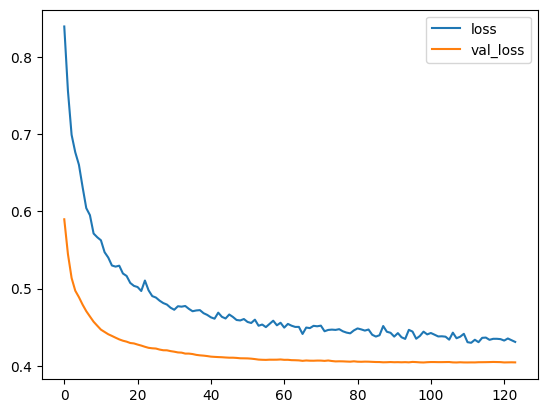

In [179]:
# CHOOSING HYPE PARAMS
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']


plt.plot(loss, label='loss')
plt.plot(val_loss, label='val_loss')
plt.legend()
plt.show()

In [148]:
y_train_pred_proba = tf.sigmoid(model.predict(x_train)).numpy()
y_test_pred_proba = tf.sigmoid(model.predict(x_test)).numpy()
y_train_pred = np.where(y_train_pred_proba > 0.5, 1, 0)
y_test_pred = np.where(y_test_pred_proba > 0.5, 1, 0)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

f1_train, precision_train, recall_train = f1_score(y_train, y_train_pred[:,0])
f1_test, precision_test, recall_test = f1_score(y_test, y_test_pred[:,0])

print(f"Train Accuracy: {train_accuracy}, Train F1 Score: {f1_train}, Precision: {precision_train}, Recall: {recall_train}")
print(f"Test Accuracy: {test_accuracy}, Test F1 Score: {f1_test}, Precision: {precision_test}, Recall: {recall_test}")

177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step
Train Accuracy: 0.8155839545615904, Train F1 Score: 0.6127469250838614, Precision: 0.5494652406417112, Recall: 0.6925021061499579
Test Accuracy: 0.8005677785663591, Test F1 Score: 0.5873715124816447, Precision: 0.5361930294906166, Recall: 0.6493506493506493


In [ ]:
lambda_ = [0.1, 0.001, 0.001, 0.0001, 0.00001]

val_loss = []

for lam in lambda_:
    model = Sequential([
        Dense(units=64, activation='relu', kernel_regularizer=l2(lam)),
        Dense(units=32, activation='relu', kernel_regularizer=l2(lam)),
        Dense(units=16, activation='relu', kernel_regularizer=l2(lam)),
        Dense(units=1, activation='linear'),
    ]
    )

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        optimizer= tf.keras.optimizers.Adam(0.0001),
        metrics=['accuracy']
    )
        # monitoring val_loss monitors the probability from the sigmoid which is better than evaluating result after applying the threshold.
        # if 2 models predict 0.4 and 0.3 to same example, both evaluate to 0 for a 0.5 threshold and have same effect for accuracy, but the 0.3 model is closer to correct label 0 than the 0.4 model.
    early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

    model.fit(x_train, y_train, epochs= 200, validation_split= 0.2, callbacks=[early_stop], batch_size= 32,)
    val_loss.append(min(model.history.history['val_loss']))


Epoch 1/200


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7304 - loss: 10.1112 - val_accuracy: 0.7507 - val_loss: 9.0471
Epoch 2/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 8.8029 - val_accuracy: 0.7507 - val_loss: 7.8627
Epoch 3/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 7.6752 - val_accuracy: 0.7507 - val_loss: 6.8259
Epoch 4/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 6.6963 - val_accuracy: 0.7507 - val_loss: 5.9227
Epoch 5/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 5.8465 - val_accuracy: 0.7507 - val_loss: 5.1371
Epoch 6/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 5.1084 - val_accuracy: 0.7507 - val_loss: 4.4566
Epoch 7/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7306 - loss: 4.4680 - val_accuracy: 0.7516 - val_loss: 3.8671
Epoch 8/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7346 - loss: 3.9146 - val_accuracy: 0.757

KeyboardInterrupt: 